+ nhìn chung với mạng tuần tự thì SELU ( scale elu)  > ELU > leaky relu > relu > tanh > logistic.
+ nếu cấu trúc mạng không cho phép tự chuẩn hóa ( deep and wide) thì elu hoạt động tốt hơn.
+ Nếu quan trọng về thời gian dự đoán hãy dùng leaky relu,
+ Mạng quá khớp RReLU
+ tập huấn luyện lớn PReLu
+ Dùng nhiều nhất ReLu

In [ ]:
import tensorflow as tf
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

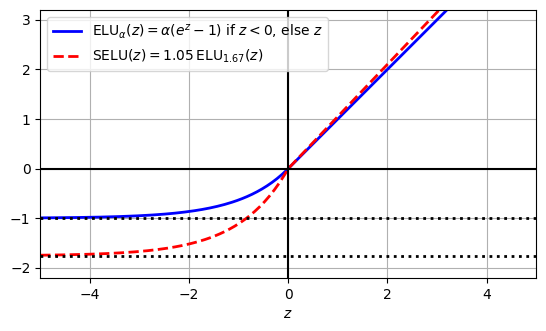

In [ ]:
## Selu

from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
# (see equation 14 in the paper):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="selu",
                                    kernel_initializer="lecun_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))


In [ ]:

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

4422102/4422102 [==============================] - 0s 0us/step


In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [ ]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [ ]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 [==============================] - 72s 31ms/step - loss: 1.5965 - accuracy: 0.3779 - val_loss: 2.1374 - val_accuracy: 0.2650
Epoch 2/5
1719/1719 [==============================] - 53s 31ms/step - loss: 1.2244 - accuracy: 0.5074 - val_loss: 0.8979 - val_accuracy: 0.6336
Epoch 3/5
1719/1719 [==============================] - 53s 31ms/step - loss: 0.8703 - accuracy: 0.6479 - val_loss: 0.8079 - val_accuracy: 0.6850
Epoch 4/5
1719/1719 [==============================] - 53s 31ms/step - loss: 0.7294 - accuracy: 0.7294 - val_loss: 0.8293 - val_accuracy: 0.6890
Epoch 5/5
1719/1719 [==============================] - 52s 30ms/step - loss: 0.6385 - accuracy: 0.7709 - val_loss: 0.6137 - val_accuracy: 0.7830


In [ ]:
# sử dụng relu để so sánh
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="relu",
                                    kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

In [ ]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 [==============================] - 66s 30ms/step - loss: 2.0716 - accuracy: 0.1907 - val_loss: 1.6748 - val_accuracy: 0.2946
Epoch 2/5
1719/1719 [==============================] - 46s 27ms/step - loss: 1.3955 - accuracy: 0.4365 - val_loss: 1.0519 - val_accuracy: 0.5608
Epoch 3/5
1719/1719 [==============================] - 45s 26ms/step - loss: 0.9688 - accuracy: 0.6223 - val_loss: 0.8620 - val_accuracy: 0.6802
Epoch 4/5
1719/1719 [==============================] - 44s 25ms/step - loss: 0.8191 - accuracy: 0.6905 - val_loss: 0.7548 - val_accuracy: 0.7288
Epoch 5/5
1719/1719 [==============================] - 44s 25ms/step - loss: 0.7281 - accuracy: 0.7297 - val_loss: 0.8134 - val_accuracy: 0.6978


# Batch Normalization

In [ ]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [ ]:

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(300, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [ ]:

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 batch_normalization_3 (Bat  (None, 784)               3136      
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 300)               235500    
                                                                 
 batch_normalization_4 (Bat  (None, 300)               1200      
 chNormalization)                                                
                                                                 
 dense_4 (Dense)             (None, 100)               30100     
                                                                 
 batch_normalization_5 (Bat  (None, 100)              

In [ ]:
[(var.name, var.trainable) for var in model.layers[1].variables]

[('batch_normalization_3/gamma:0', True),
 ('batch_normalization_3/beta:0', True),
 ('batch_normalization_3/moving_mean:0', False),
 ('batch_normalization_3/moving_variance:0', False)]

In [ ]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics="accuracy")
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 [==============================] - 11s 5ms/step - loss: 0.5555 - accuracy: 0.8095 - val_loss: 0.3942 - val_accuracy: 0.8568
Epoch 2/2
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4056 - accuracy: 0.8565 - val_loss: 0.3609 - val_accuracy: 0.8692


In [ ]:
# dùng batchnorm trước hàm kích hoạt

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics="accuracy")
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6046 - accuracy: 0.7988 - val_loss: 0.4316 - val_accuracy: 0.8486
Epoch 2/2
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4246 - accuracy: 0.8513 - val_loss: 0.3786 - val_accuracy: 0.8642


# Gradient Clipping

In [ ]:
# kĩ thuật giới hạn gradient trong một khoảng nhất định để hạn chế bùng nổ gradient,
# Kĩ thuật này được sử dụng nhiều trong mạng nơ-ron hồi tiếp vì chuẩn hóa theo Batch khó dùng trong mạng này

In [ ]:
# clip value
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)
# clip norm
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

# Tái sử dụng các tầng đã huấn luyện

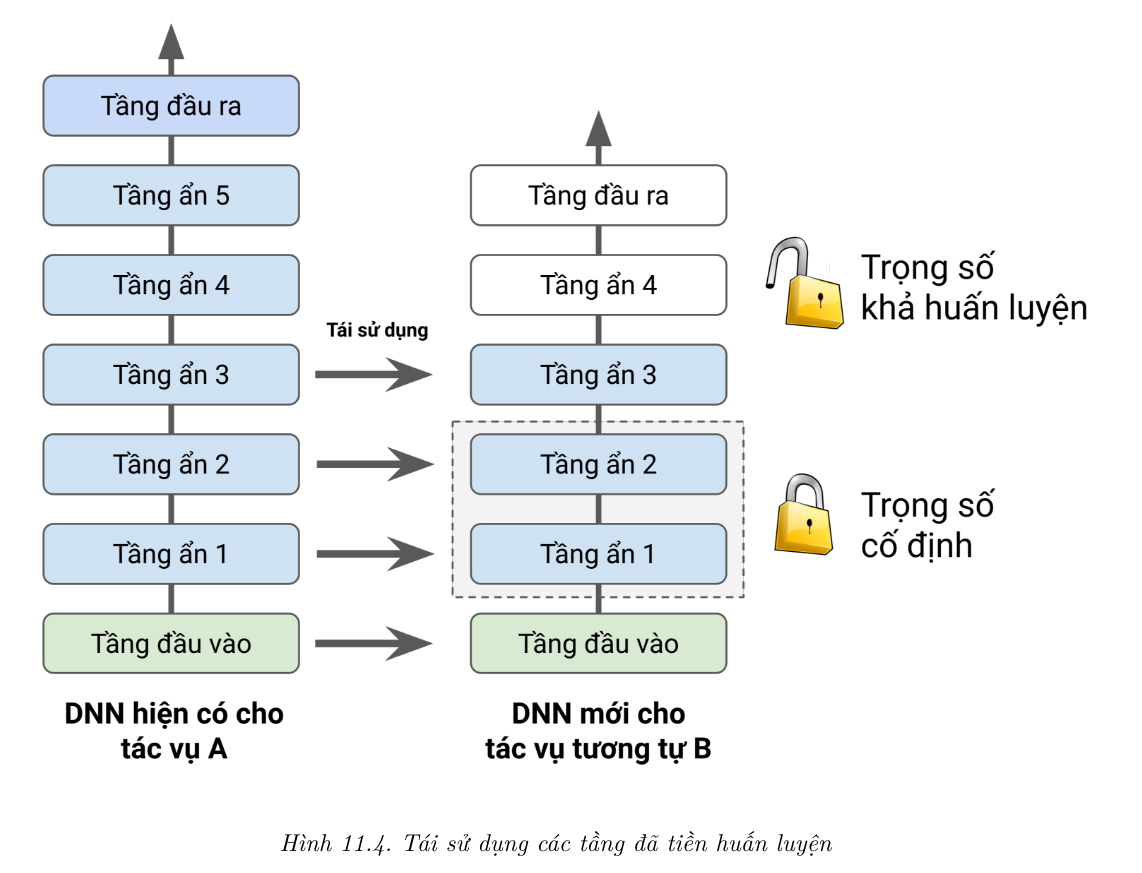

In [ ]:
# extra code – split Fashion MNIST into tasks A and B, then train and save
#              model A to "my_model_A".

pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

tf.random.set_seed(42)

model_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))
model_A.save("my_model_A")

Epoch 1/20
1376/1376 [==============================] - 6s 4ms/step - loss: 1.1968 - accuracy: 0.6386 - val_loss: 0.7111 - val_accuracy: 0.7806
Epoch 2/20
1376/1376 [==============================] - 5s 3ms/step - loss: 0.6138 - accuracy: 0.8033 - val_loss: 0.5223 - val_accuracy: 0.8333
Epoch 3/20
1376/1376 [==============================] - 5s 4ms/step - loss: 0.4925 - accuracy: 0.8454 - val_loss: 0.4455 - val_accuracy: 0.8561
Epoch 4/20
1376/1376 [==============================] - 5s 3ms/step - loss: 0.4308 - accuracy: 0.8621 - val_loss: 0.3993 - val_accuracy: 0.8714
Epoch 5/20
1376/1376 [==============================] - 5s 4ms/step - loss: 0.3925 - accuracy: 0.8722 - val_loss: 0.3704 - val_accuracy: 0.8772
Epoch 6/20
1376/1376 [==============================] - 5s 4ms/step - loss: 0.3662 - accuracy: 0.8788 - val_loss: 0.3515 - val_accuracy: 0.8789
Epoch 7/20
1376/1376 [==============================] - 5s 3ms/step - loss: 0.3472 - accuracy: 0.8841 - val_loss: 0.3351 - val_accuracy:

In [ ]:
# extra code – train and evaluate model B, without reusing model A

tf.random.set_seed(42)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))
model_B.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 [==============================] - 2s 54ms/step - loss: 0.7467 - accuracy: 0.4400 - val_loss: 0.7167 - val_accuracy: 0.4837
Epoch 2/20
7/7 [==============================] - 0s 17ms/step - loss: 0.7214 - accuracy: 0.4450 - val_loss: 0.6972 - val_accuracy: 0.4896
Epoch 3/20
7/7 [==============================] - 0s 17ms/step - loss: 0.6995 - accuracy: 0.4500 - val_loss: 0.6790 - val_accuracy: 0.5361
Epoch 4/20
7/7 [==============================] - 0s 16ms/step - loss: 0.6780 - accuracy: 0.5150 - val_loss: 0.6656 - val_accuracy: 0.5925
Epoch 5/20
7/7 [==============================] - 0s 16ms/step - loss: 0.6627 - accuracy: 0.6200 - val_loss: 0.6532 - val_accuracy: 0.6597
Epoch 6/20
7/7 [==============================] - 0s 30ms/step - loss: 0.6484 - accuracy: 0.6700 - val_loss: 0.6418 - val_accuracy: 0.7141
Epoch 7/20
7/7 [==============================] - 0s 17ms/step - loss: 0.6351 - accuracy: 0.7250 - val_loss: 0.6315 - val_accuracy: 0.7399
Epoch 8/20
7/7 [===========

[0.5190838575363159, 0.8980000019073486]

Sử dụng model A để train model B

In [ ]:
#Model B reaches 89.80% accuracy on the test set. Now let's try reusing the pretrained model A.

tf.random.set_seed(42)  # extra code – ensure reproducibility
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())


model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
# vì tầng cuối cùng mới được khởi tạo ngẫu nhiên lỗi của mô hình sẽ tương đối lớn ( ít nhất trong vài epoch đầu tiên)
# Điều này có thể gây ra  những lỗi gradient lớn và làm hỏng các trọng số được tái sử dụng
# Để tránh điều này ta có thể đóng băng những tầng tái sử dụng trong những epoch đầu tiên
# nhằm cho cá tầng mới có thêm thời gian học được trọng số phù hợp.
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])



In [ ]:

history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))

Epoch 1/4
7/7 [==============================] - 2s 151ms/step - loss: 0.8502 - accuracy: 0.4600 - val_loss: 0.6399 - val_accuracy: 0.5391
Epoch 2/4
7/7 [==============================] - 0s 50ms/step - loss: 0.6043 - accuracy: 0.6000 - val_loss: 0.5446 - val_accuracy: 0.7765
Epoch 3/4
7/7 [==============================] - 0s 41ms/step - loss: 0.5318 - accuracy: 0.7950 - val_loss: 0.5236 - val_accuracy: 0.8150
Epoch 4/4
7/7 [==============================] - 0s 50ms/step - loss: 0.5077 - accuracy: 0.8650 - val_loss: 0.5182 - val_accuracy: 0.8180
Epoch 1/16
7/7 [==============================] - 2s 122ms/step - loss: 0.4836 - accuracy: 0.8800 - val_loss: 0.4714 - val_accuracy: 0.8675
Epoch 2/16
7/7 [==============================] - 0s 38ms/step - loss: 0.4410 - accuracy: 0.9050 - val_loss: 0.4322 - val_accuracy: 0.8932
Epoch 3/16
7/7 [==============================] - 0s 36ms/step - loss: 0.4012 - accuracy: 0.9350 - val_loss: 0.4061 - val_accuracy: 0.9139
Epoch 4/16
7/7 [=============

Độ chính xác được cải thiện nhiều hơn


Tuy nhiên transfer learning không phù hợp với mạng kết nối dày đặc nhỏ ,các mạng dày đặc nhỏ học được ít khuôn mẫu và các mạng dày đặc lại học các khuôn mẫu rất cụ thể không thực sự hữu ích trên các tác vụ khác. Tranfer learning hoạt động tốt nhất với các mạng nơ-ron tích chập sâu.

Trong bài toán rất nhiều dữ liệu không gán nhãn, ta có thể dùng chúng để huấn luyện một mô hình học không giám sát ( ví dụ bộ tự mã hóa hoặc mạng đối sinh GAN). Sau đó tái sử dụng các tầng thấp của bộ tự mã hóa hoặc bộ phận đặc biệt của GAN, thêm tầng đầu ra cho tác vụ của ta và tinh chỉnh mô hình cuối cùng bằng học có giám sát (tức là huấn luyện với các mẫu có nhãn)

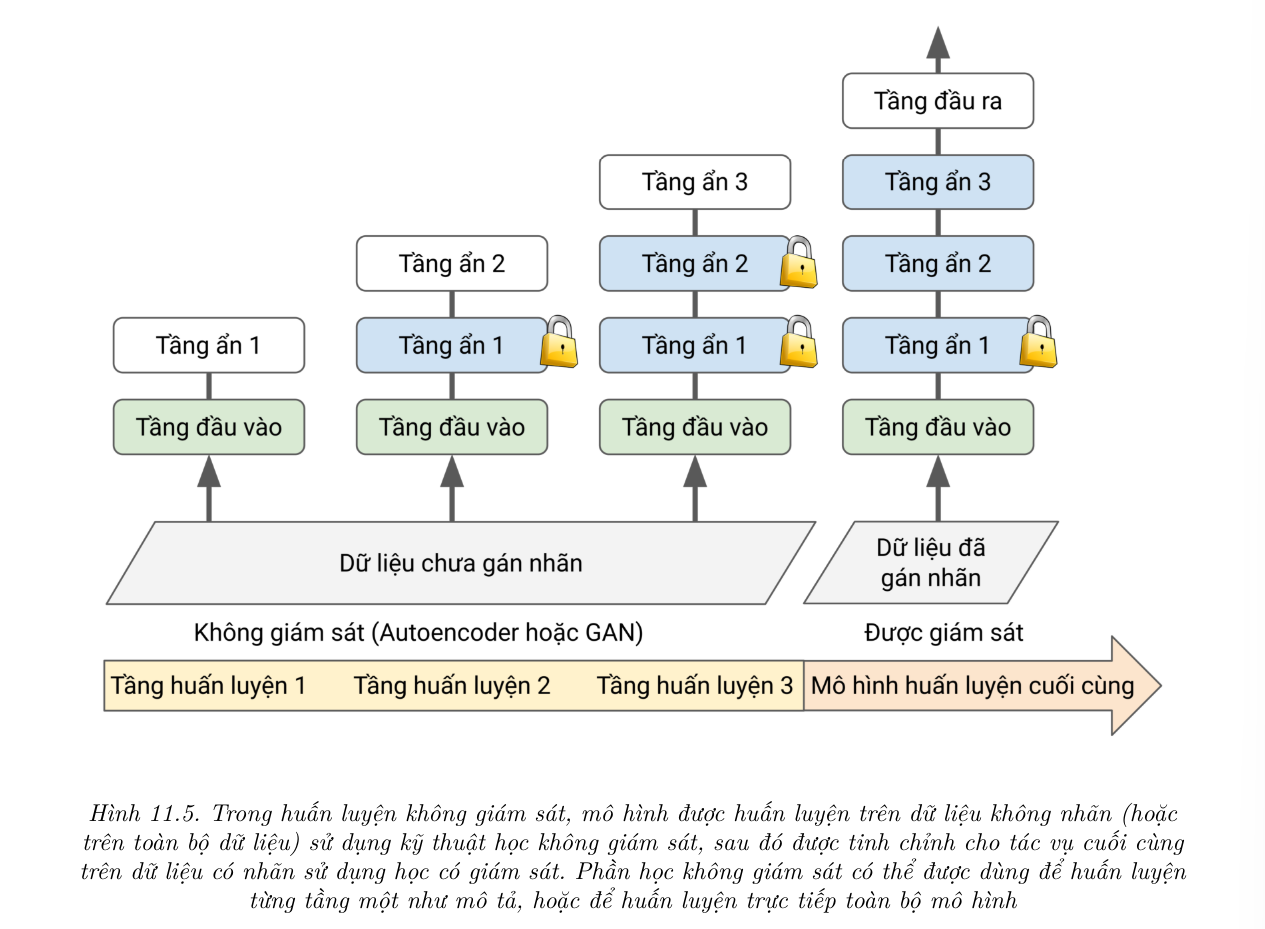

Self-supervised learning is when you automatically generate the
labels from the data itself, as in the text-masking example, then you
train a model on the resulting “labeled” dataset using supervised
learning techniques.

# Faster Optimizers

In [ ]:

def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def build_and_train_model(optimizer):
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

In [ ]:
history_sgd = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 7s 3ms/step - loss: 0.7033 - accuracy: 0.7597 - val_loss: 0.4976 - val_accuracy: 0.8186
Epoch 2/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4672 - accuracy: 0.8345 - val_loss: 0.4503 - val_accuracy: 0.8350
Epoch 3/10
1719/1719 [==============================] - 11s 7ms/step - loss: 0.4226 - accuracy: 0.8513 - val_loss: 0.4209 - val_accuracy: 0.8510
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3957 - accuracy: 0.8609 - val_loss: 0.3782 - val_accuracy: 0.8648
Epoch 5/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3734 - accuracy: 0.8670 - val_loss: 0.3642 - val_accuracy: 0.8656
Epoch 6/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3595 - accuracy: 0.8722 - val_loss: 0.3670 - val_accuracy: 0.8656
Epoch 7/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3426 - accuracy: 0.8772 - val_loss: 0.3646 - val_accuracy

# Momentum optimization

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

In [ ]:
history_momentum = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.6982 - accuracy: 0.7599 - val_loss: 0.5147 - val_accuracy: 0.8084
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4665 - accuracy: 0.8353 - val_loss: 0.4487 - val_accuracy: 0.8350
Epoch 3/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4235 - accuracy: 0.8492 - val_loss: 0.4109 - val_accuracy: 0.8522
Epoch 4/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3961 - accuracy: 0.8603 - val_loss: 0.3882 - val_accuracy: 0.8564
Epoch 5/10
1719/1719 [==============================] - 10s 6ms/step - loss: 0.3760 - accuracy: 0.8660 - val_loss: 0.3691 - val_accuracy: 0.8612
Epoch 6/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3633 - accuracy: 0.8702 - val_loss: 0.3762 - val_accuracy: 0.8610
Epoch 7/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3473 - accuracy: 0.8745 - val_loss: 0.3742 - val_accuracy

# Nesterov Accelerated Gradient

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9,
                                    nesterov=True)

In [ ]:
history_nesterov = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.6953 - accuracy: 0.7639 - val_loss: 0.4921 - val_accuracy: 0.8270
Epoch 2/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4657 - accuracy: 0.8374 - val_loss: 0.4426 - val_accuracy: 0.8408
Epoch 3/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4196 - accuracy: 0.8517 - val_loss: 0.4107 - val_accuracy: 0.8554
Epoch 4/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3932 - accuracy: 0.8620 - val_loss: 0.3858 - val_accuracy: 0.8640
Epoch 5/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.3721 - accuracy: 0.8694 - val_loss: 0.3781 - val_accuracy: 0.8642
Epoch 6/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3578 - accuracy: 0.8720 - val_loss: 0.3825 - val_accuracy: 0.8656
Epoch 7/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3434 - accuracy: 0.8759 - val_loss: 0.3745 - val_accuracy:

# AdaGrad

In [ ]:
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)
history_adagrad = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 1.0193 - accuracy: 0.6867 - val_loss: 0.6832 - val_accuracy: 0.7732
Epoch 2/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.6388 - accuracy: 0.7871 - val_loss: 0.5845 - val_accuracy: 0.8022
Epoch 3/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5725 - accuracy: 0.8062 - val_loss: 0.5412 - val_accuracy: 0.8162
Epoch 4/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.5375 - accuracy: 0.8181 - val_loss: 0.5173 - val_accuracy: 0.8224
Epoch 5/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.5145 - accuracy: 0.8244 - val_loss: 0.4989 - val_accuracy: 0.8274
Epoch 6/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4979 - accuracy: 0.8295 - val_loss: 0.4867 - val_accuracy: 0.8306
Epoch 7/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4850 - accuracy: 0.8330 - val_loss: 0.4758 - val_accuracy:

# RMSProp

In [ ]:
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)
history_rmsprop = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.5183 - accuracy: 0.8123 - val_loss: 0.4388 - val_accuracy: 0.8338
Epoch 2/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3937 - accuracy: 0.8572 - val_loss: 0.4195 - val_accuracy: 0.8428
Epoch 3/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3674 - accuracy: 0.8682 - val_loss: 0.3740 - val_accuracy: 0.8698
Epoch 4/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3562 - accuracy: 0.8751 - val_loss: 0.3721 - val_accuracy: 0.8720
Epoch 5/10
1719/1719 [==============================] - 8s 4ms/step - loss: 0.3476 - accuracy: 0.8775 - val_loss: 0.4023 - val_accuracy: 0.8602
Epoch 6/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.3440 - accuracy: 0.8793 - val_loss: 0.4138 - val_accuracy: 0.8672
Epoch 7/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3414 - accuracy: 0.8812 - val_loss: 0.4582 - val_accuracy:

# Adam Optimization

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9,
                                     beta_2=0.999)
history_adam = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 [==============================] - 10s 5ms/step - loss: 0.4993 - accuracy: 0.8224 - val_loss: 0.4162 - val_accuracy: 0.8416
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.3797 - accuracy: 0.8621 - val_loss: 0.3910 - val_accuracy: 0.8530
Epoch 3/10
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3449 - accuracy: 0.8734 - val_loss: 0.3385 - val_accuracy: 0.8782
Epoch 4/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3188 - accuracy: 0.8829 - val_loss: 0.3367 - val_accuracy: 0.8786
Epoch 5/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.2999 - accuracy: 0.8879 - val_loss: 0.3187 - val_accuracy: 0.8776
Epoch 6/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.2853 - accuracy: 0.8939 - val_loss: 0.3457 - val_accuracy: 0.8814
Epoch 7/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.2736 - accuracy: 0.8970 - val_loss: 0.3552 - val_accuracy

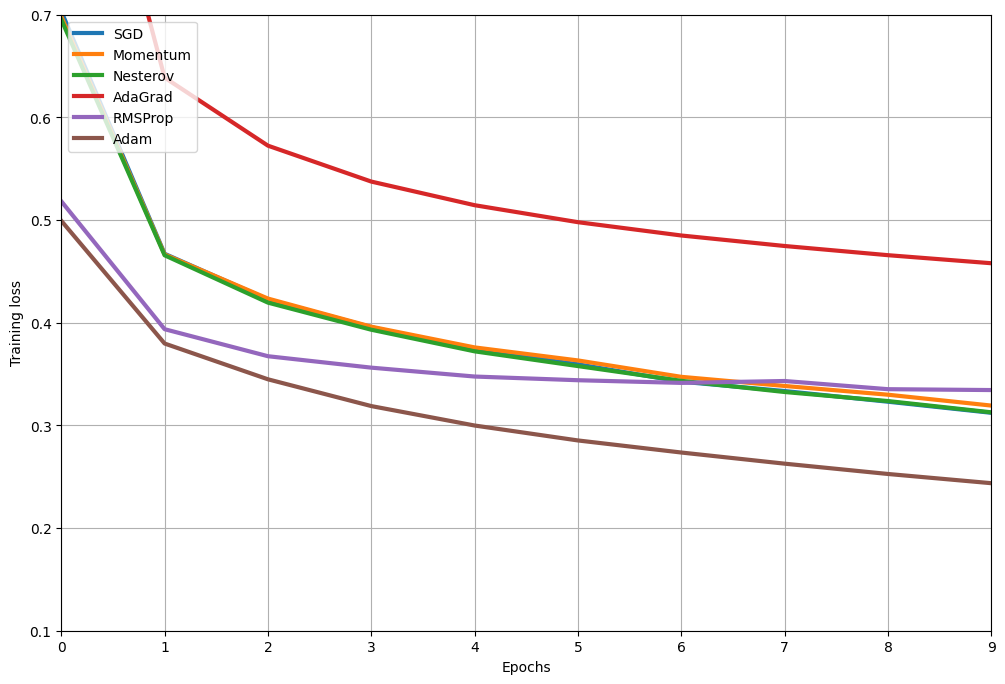

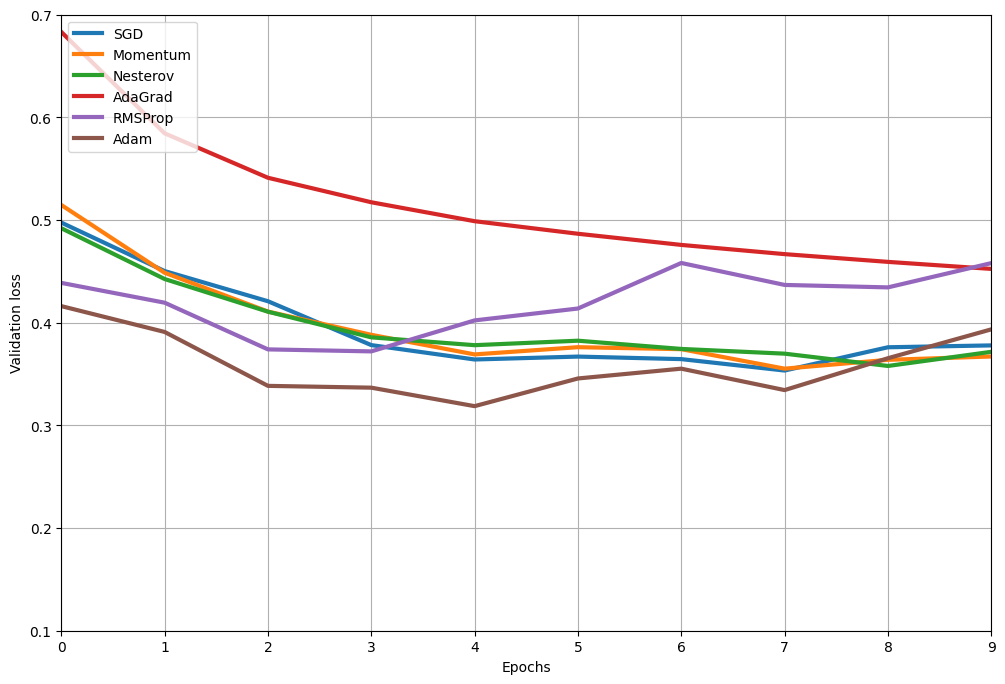

In [ ]:

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
    ),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0.1, 0.7])
    plt.show()

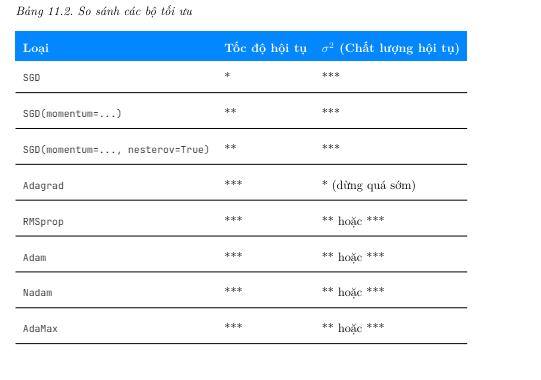

# Learning rate scheduling


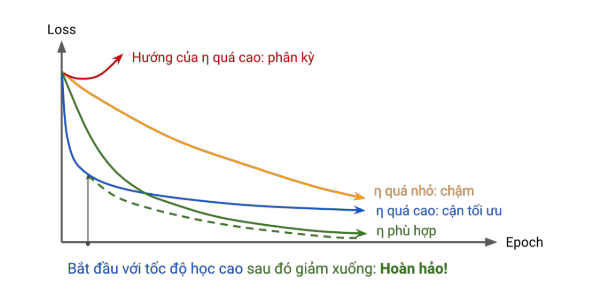

# Power Scheduling
learning_rate = initial_learning_rate / (1 + step / decay_steps)**power
- Keras uses power = 1.

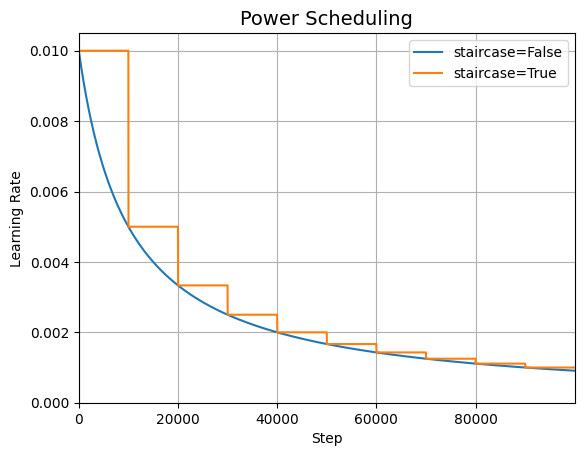

In [ ]:
initial_learning_rate = 0.01
decay_rate = 1.0
decay_steps = 10_000

steps = np.arange(100_000)
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1.0,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
history_power_scheduling = build_and_train_model(optimizer)

# Exponential Scheduling
learning_rate = initial_learning_rate * decay_rate ** (step / decay_steps)

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
history_exponential_scheduling = build_and_train_model(optimizer)

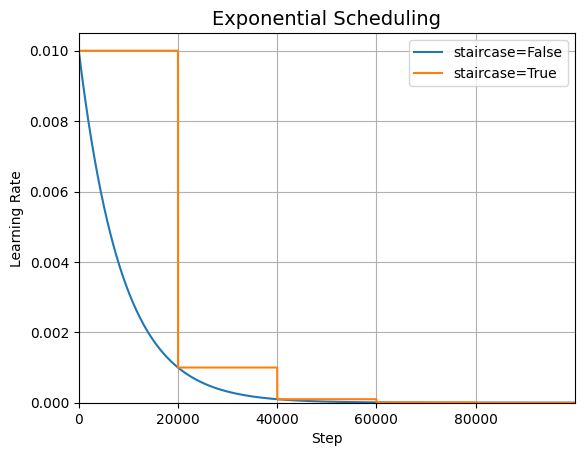

In [ ]:
initial_learning_rate = 0.01
decay_rate = 0.1
decay_steps = 20_000

steps = np.arange(100_000)
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Avoiding Overfitting Through Regularization

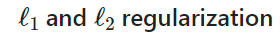

In [ ]:
layer = tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal",
                              kernel_regularizer=tf.keras.regularizers.l2(0.01))

In [ ]:
tf.random.set_seed(42)

In [ ]:
from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax")
])

In [ ]:
# extra code – compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

# Dropout

In [ ]:
tf.random.set_seed(42)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [ ]:
# extra code – compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

In [ ]:
model.evaluate(X_train, y_train)